# Toroidal (Circular) Boundary Conditions Demo

This notebook demonstrates how to use the new toroidal (circular) boundary condition kernels in the `wta2d` package, and compares them with the default open-boundary kernels.

We will:

- Build a shared random input pattern.
- Run the network once with **open** boundaries and once with **toroidal** boundaries.
- Visualize and compare the resulting kernels and activities.


In [1]:
import pathlib, sys

# Ensure the local repo (with the `wta2d` package) is on the path
root = pathlib.Path.cwd()
if (root / "wta2d").exists() and str(root) not in sys.path:
    sys.path.insert(0, str(root))

import numpy as np
import matplotlib.pyplot as plt
import wta2d
from wta2d import viz

wta2d.__version__


'0.1.0'

In [2]:
# Build a shared random input and run with open vs toroidal boundaries
side = 50
tlen = 5000
rng = np.random.default_rng(0)

N, _, _ = wta2d.make_grid(side)
Inp = wta2d.random_sparse_input(tlen, N, sparsity=0.55, scale=1.0, rng=rng)

xs_open, Inp_open, We_open, Wi_open, aa_open = wta2d.run(
    side=side,
    tlen=tlen,
    Inp=Inp,
    boundary="open",
)

xs_toroidal, Inp_toroidal, We_toroidal, Wi_toroidal, aa_toroidal = wta2d.run(
    side=side,
    tlen=tlen,
    Inp=Inp,
    boundary="toroidal",
)


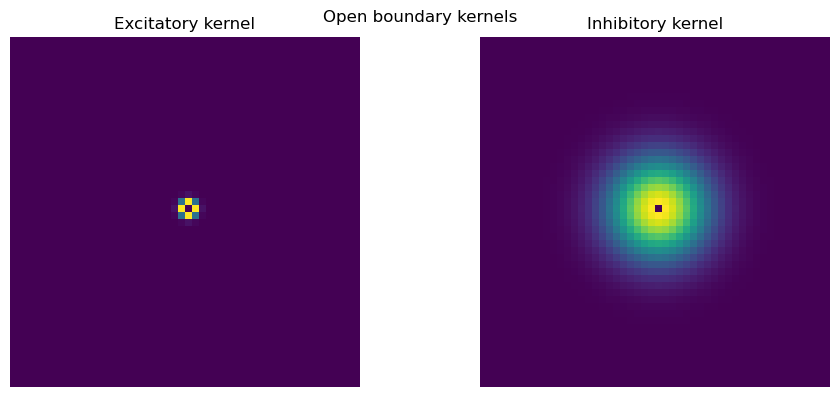

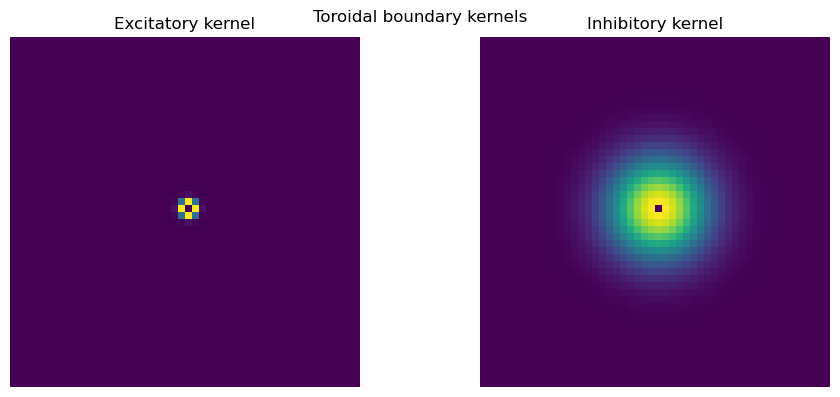

In [3]:
# Compare kernels for open vs toroidal boundaries
fig1 = viz.plot_kernels(We_open, Wi_open, aa_open)
fig1.suptitle("Open boundary kernels")

fig2 = viz.plot_kernels(We_toroidal, Wi_toroidal, aa_toroidal)
fig2.suptitle("Toroidal boundary kernels")

plt.show()


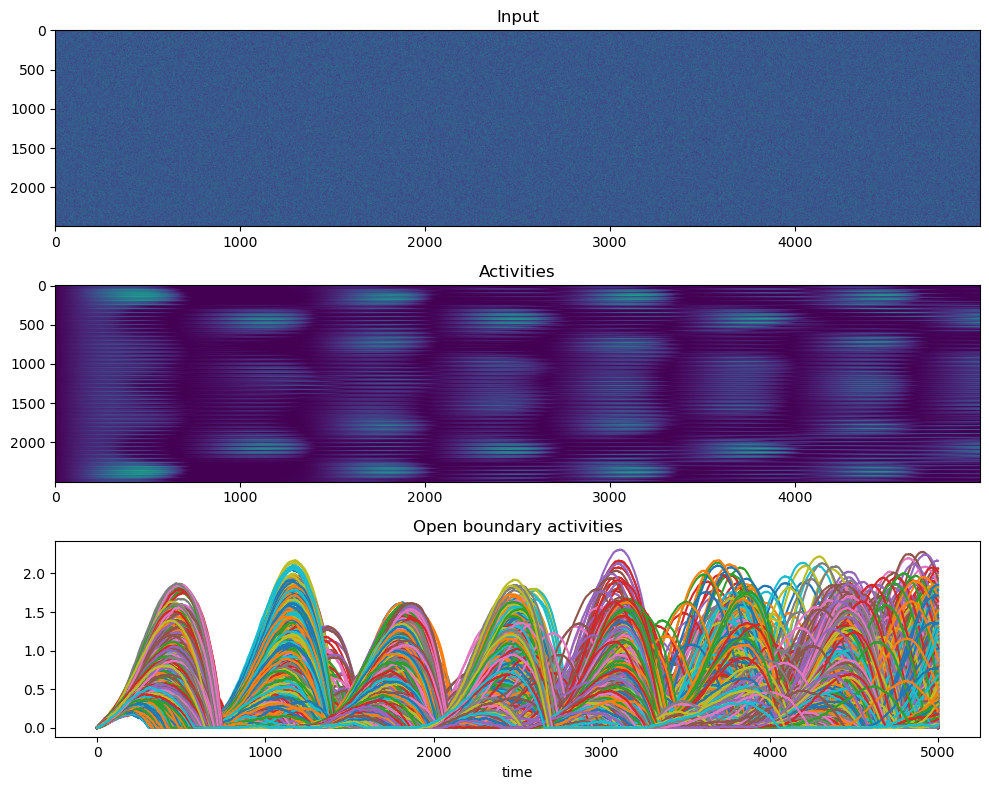

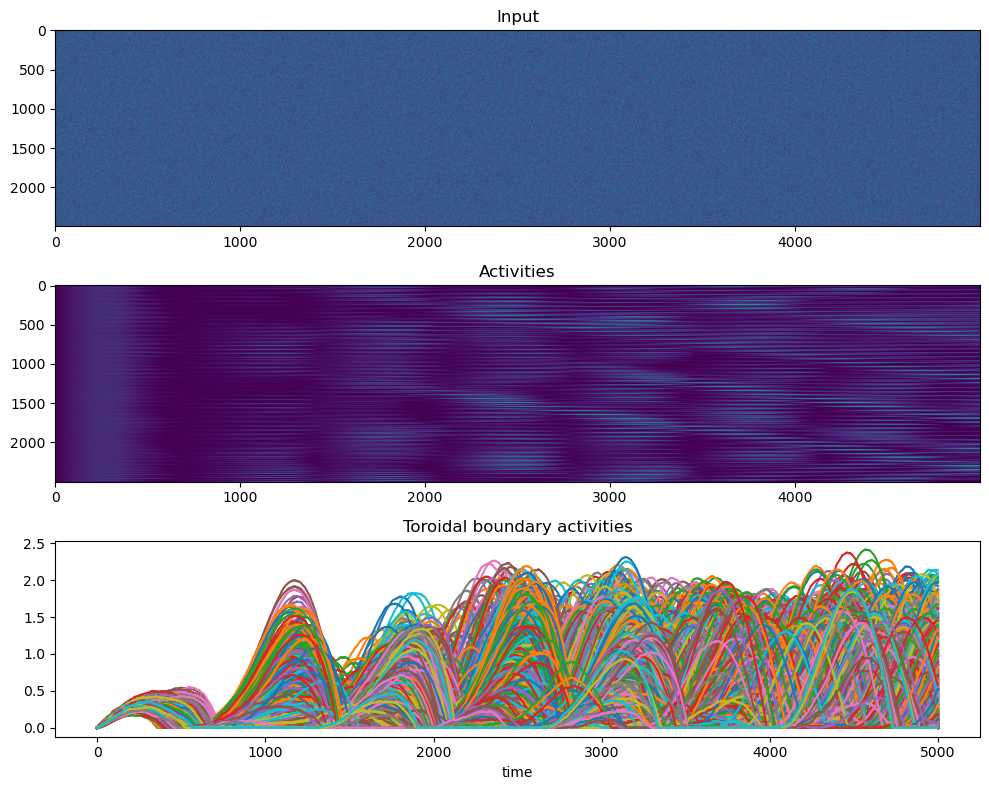

In [4]:
# Compare activity summaries
viz.plot_summary(xs_open, Inp_open, title_activities="Open boundary activities")
viz.plot_summary(xs_toroidal, Inp_toroidal, title_activities="Toroidal boundary activities")
plt.show()


In [ ]:
from wta2d import save_gif
from IPython.display import Image, display

# GIFs are saved under the Examples folder (every 10 steps by default; nframe caps total frames)
save_gif(xs_open, aa_open, "wta2d_open_noborder.gif", cmap="plasma", border=0, nframe=30)
save_gif(xs_toroidal, aa_toroidal, "wta2d_toroidal_noborder.gif", cmap="plasma", border=0, nframe=30)

# Display the generated GIFs from Examples
display(Image(filename="Examples/wta2d_open_noborder.gif"))
display(Image(filename="Examples/wta2d_toroidal_noborder.gif"))